# QUE TRIMESTRE ES EL MAS RENTABLE

In [ ]:
# Instalación de librerías
!pip install yfinance plotly

In [ ]:
# Importación de librerías
import yfinance as yf
import plotly.express as px

print("Librerías cargadas correctamente ✅")

Librerías cargadas correctamente ✅


In [ ]:
AMZN = yf.Ticker("AMZN")

In [ ]:
df = yf.download("AMZN", period="1y")["Close"]

/tmp/ipython-input-647966040.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AMZN", period="1y")["Close"]
[*********************100%***********************]  1 of 1 completed


In [ ]:
df

Ticker,AMZN
Date,
2024-09-12,187.000000
2024-09-13,186.490005
2024-09-16,184.889999
2024-09-17,186.880005
2024-09-18,186.429993
...,...
2025-09-05,232.330002
2025-09-08,235.839996
2025-09-09,238.240005


In [ ]:
df.head(25)

Ticker,AMZN
Date,
2024-09-12,187.000000
2024-09-13,186.490005
2024-09-16,184.889999
2024-09-17,186.880005
2024-09-18,186.429993
2024-09-19,189.869995
2024-09-20,191.600006
2024-09-23,193.880005
2024-09-24,193.960007


In [3]:
# Agrupar precios por trimestre y calcular rentabilidad
df_q = df.resample("QE").last()  # último precio de cada trimestre
df_q["rentabilidad"] = df_q.pct_change() * 100  # % de cambio trimestral

# Identificar el trimestre más rentable
max_idx = df_q["rentabilidad"].idxmax()
max_rentabilidad = df_q.loc[max_idx, "rentabilidad"]

print("Rentabilidades por trimestre:")
print(df_q)

print(f"\nEl trimestre más rentable fue {max_idx.strftime('%Y-Q%q')} "
      f"con una rentabilidad de {max_rentabilidad:.2f}%")


Rentabilidades por trimestre:
Ticker            AMZN  rentabilidad
Date                                
2024-09-30  186.330002           NaN
2024-12-31  219.389999     17.742713
2025-03-31  190.259995    -13.277727
2025-06-30  219.389999     15.310631
2025-09-30  234.050003      6.682166

El trimestre más rentable fue 2024-Q%q con una rentabilidad de 17.74%


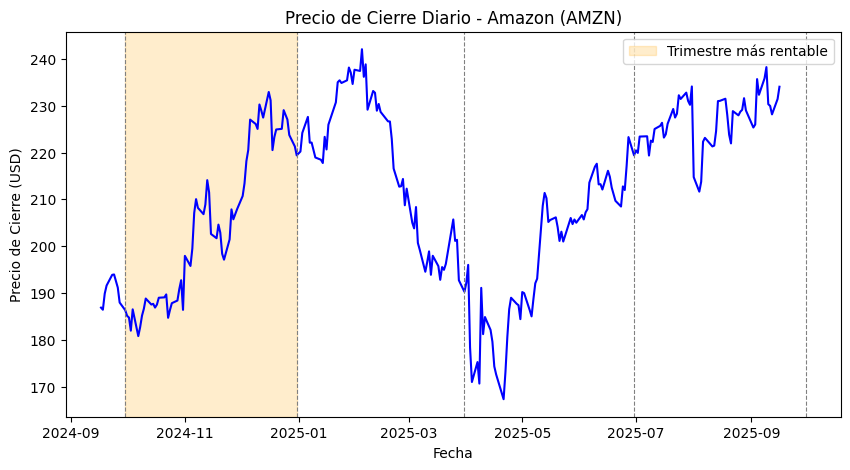

In [2]:
# --- GRAFICO DE LINEA (precios diarios) ---
plt.figure(figsize=(10,5))
plt.plot(df.index, df, color="blue", linewidth=1.5)

# Líneas verticales al cierre de cada trimestre
for fecha in df_q.index:
    plt.axvline(fecha, color="gray", linestyle="--", linewidth=0.8)

# Marcar el trimestre más rentable
plt.axvspan(df_q.index[df_q.index.get_loc(max_idx)-1] if df_q.index.get_loc(max_idx) > 0 else df.index[0],
            max_idx, color="orange", alpha=0.2, label="Trimestre más rentable")

plt.title("Precio de Cierre Diario - Amazon (AMZN)")
plt.xlabel("Fecha")
plt.ylabel("Precio de Cierre (USD)")
plt.legend()
plt.show()
